# Машинное обучение, ШАД
## Домашнее задание 5


**Правила:**

* Дедлайн **31 октября 15:00**. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Для сдачи задания нужно загрузить **ноутбук в формате `ipynb`** в ЛМС.
* Выполнять задание необходимо полностью самостоятельно.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * прикрепив ее в ЛМС в форматах `pdf`, `png` или `jpg` *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image`;
  * в виде $\LaTeX$ в markdown-ячейках или в отдельном `pdf`-файле.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 2 балла
* Задача 2 &mdash; 2 балла
* Задача 3 &mdash; 2 балла
* Задача 4 &mdash; 2 балла


In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from IPython.display import Math
import tqdm as tqdm

import typing as tp

np.random.seed(0)

plt.rcParams.update({
    'text.usetex' : True,
    'font.size' : 14
})

---
### Задача 1. 

> *В условии этой задачи подробно расписаны алгоритмы решения каждого пункта. Перед выполнением ознакомьтесь также с примерами, которые были рассказаны на лекции, они во многом аналогичны. При возникновении затруднений спрашивайте вопросы в чате.*

Пусть $X_1,...,X_n$ &mdash; выборка из экспоненциального распределения с плотностью $p_\theta(x) = \theta e^{-\theta x},$ где $x>0, \theta>0$. Такое распределение описывает время до наступления некоторого события. Например, таким событием может быть поступление очередного заказа таксисту или курьеру службы доставки. В таком случае $X_i$ &mdash; время ожидания $i$-го заказа после завершения предыдущего. Параметр $\theta$ имеет смысл интенсивности заказов в единицу времени. Следовательно, чем больше $\theta$, тем меньше среднее значение $X_i$. Точнее $\mathsf{E}_\theta X_i = 1/\theta$.


При выполнении задач используйте то, что $\mathsf{E}_\theta X_i^k = k!/\theta^k$.

**1.** Предложите асимптотически нормальную оценку $\theta$ и найдите ее асимптотическую дисперсию.

* Для выполнения этого пункта запишите центральную предельную теорему. Для какой функции $h(\theta)$ тем самым получилась асимптотически нормальная оценка?

* Какую функцию нужно применить, чтобы получить оценку для $\theta$?

* Воспользуйтесь дельта-методом, чтобы получить асимптотически нормальную оценку $\theta$. Не забудьте проверить применимость дельта-метода.

* Посчитайте ее асимптотическую дисперсию по формуле, которую дает дельта-метод. Обратите внимание, что в качестве аргумента производной нужно взять ту величину, для которой мы сначала построили оценку, то есть для $h(\theta)$.

Известно, что $\mathsf{E}_\theta X = 1/\theta$, а  $\mathsf{D}_\theta X = \mathsf{E}_\theta X^2 - (\mathsf{E}_\theta X)^2 =  1/\theta^2 $. Рассмотрим выборочное среднее $\overline{X}_n = \sum_{i=1}^{n} X_i$. В соответствии с ЦПТ, для выборочного среднего $\overline{X}_n$ справедливо:

$
\sqrt{n} (\overline{X}_n - 1/\theta) \stackrel{d}{\rightarrow} \mathcal{N}(0,\,1/\theta^2),\; n \rightarrow \infty,
$

иными словами, $\overline{X}_n$ - асимптотически нормальная оценка (а.н.о.) $1/\theta$ c асимптотиеской дисперсией $1/\theta^2$.
 
Рассмотрим функцию $h(x) = 1/x$. Так как $\theta > 0$, то $1/\theta > 0$ и $h$ является непрерывно дифференцируемой функцией для допустимых параметров. Производная равна $h'(x) = -1/x^2$, $h'(1/\theta) = -\theta^2$. В этом случае можем воспользоваться дельта-методом:

$
\sqrt{n} (h(\overline{X}_n) - h(1/\theta)) \stackrel{d_\theta}{\rightarrow} \mathcal{N}(0,\,1/\theta^2 \cdot (h'(1/\theta))^2),\; n \rightarrow \infty
$,

$
\sqrt{n} (1/\overline{X}_n - \theta) \stackrel{d_\theta}{\rightarrow} \mathcal{N}(0,\,\theta^2),\; n \rightarrow \infty
$,

то есть $\hat{\theta}_1 = h(\overline{X}_n) = 1/\overline{X}_n$ - а.н.о. $h(\mathsf{E}_\theta X) = \theta$ c асимптотиеской дисперсией $\sigma_1^2 (\theta) = \theta^2$.


In [2]:
# Parameters
theta = 1  # true value of theta
N = 10_000   # sample size
num_simulations = 10_000  # number of simulations
samples = np.random.exponential(scale=1/theta, size=(num_simulations, N))

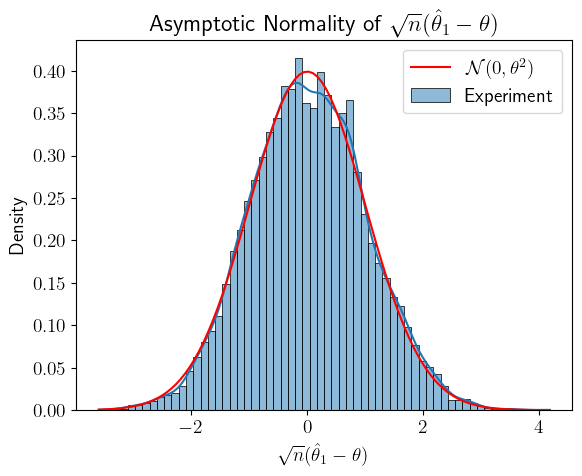

In [3]:
X_mean = np.mean(samples, axis=-1)
theta_hat_1 = 1 / X_mean

estimates_1 = np.sqrt(N) * (theta_hat_1 - theta)

mean_asymptotic_1 = 0
std_asymptotic_2 = theta

sns.histplot(estimates_1, kde=True, stat="density", label="Experiment")
x_values = np.linspace(min(estimates_1), max(estimates_1), 100)
plt.plot(x_values, sp.stats.norm.pdf(x_values, mean_asymptotic_1, std_asymptotic_2), label=r"$\mathcal{N}(0,\theta^2)$", color="red")
plt.xlabel(r"$\sqrt{n} (\hat{\theta}_1 - \theta)$")
plt.ylabel("Density")
plt.legend(loc='best')
plt.title(fr"Asymptotic Normality of $\sqrt{{n}}(\hat{{\theta}}_1 - \theta)$")
plt.show()

**2.** А почему мы применяем центральную предельную теорему именно к такой выборке? Почему бы не применить ее к выборке $X_1^2,...,X_n^2$?

Сделайте это и получите еще одну асимптотически нормальную оценку $\theta$.

Применим аналогичные рассуждения к выборке $(X_1^2,...,X_n^2) = (Y_1,...,Y_n)$. Известно $\mathsf{E}_\theta Y = \mathsf{E}_\theta X^2 = 2/\theta^2$ и $\mathsf{D}_\theta Y^2 = \mathsf{E}_\theta X^4 -  (\mathsf{E}_\theta X^2)^2= 20/\theta^4$, то для выборочного среднего $\overline{Y}_n = \sum_{i=1}^{n} Y_i$ справедлива ЦПТ:

$
\sqrt{n} (\overline{Y}_n - 2/\theta^2) \stackrel{d}{\rightarrow} \mathcal{N}(0,\,20/\theta^4),\; n \rightarrow \infty,
$

Рассмотрим функцию $g(x) = \sqrt{\frac{2}{x}} $, при $x>0$ функция является непрерывно дифференицруемой и $g'(x)=-\frac{1}{\sqrt{2}x^{3/2}}$. Воспользуемся дельта-методом:

$
\sqrt{n} (g(\overline{Y}_n) - g(2/\theta^2)) \stackrel{d}{\rightarrow} \mathcal{N}(0,\,20/\theta^4 \cdot (g'(2/\theta^2))^2),\; n \rightarrow \infty,
$

$
\sqrt{n} \left(\sqrt{\frac{2}{\overline{Y}_n}} - \theta\right) \stackrel{d}{\rightarrow} \mathcal{N}(0,\,5\theta^2/4),\; n \rightarrow \infty,
$

то есть $\hat{\theta}_2 = \sqrt{\frac{2}{\overline{Y}_n}}$ - а.н.о. $\theta$ c асимптотиеской дисперсией $\sigma_2^2 (\theta) = 5\theta^2/4$.

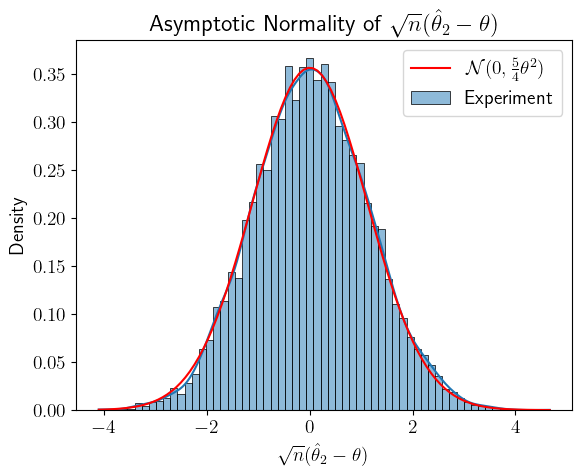

In [4]:
Y_mean = np.mean(samples**2, axis=-1)
theta_hat_2 = np.sqrt(2 / Y_mean)

estimates_2 = np.sqrt(N) * (theta_hat_2 - theta)

mean_asymptotic_2 = 0
std_asymptotic_2 = np.sqrt(1.25) * theta

sns.histplot(estimates_2, kde=True, stat="density", label="Experiment")
x_values = np.linspace(min(estimates_2), max(estimates_2), 100)
plt.plot(x_values, sp.stats.norm.pdf(x_values, mean_asymptotic_2, std_asymptotic_2), label=r"$\mathcal{N}(0,\frac{5}{4}\theta^2)$", color="red")
plt.xlabel(r"$\sqrt{n} (\hat{\theta}_2 - \theta)$")
plt.ylabel("Density")
plt.legend()
plt.title(fr"Asymptotic Normality of $\sqrt{{n}}(\hat{{\theta}}_2 - \theta)$")
plt.show()

**3.** По каждой из двух асимптотически нормальных оценок $\theta$ постройте асимптотический доверительный интервал Вальда уровня доверия $\alpha$. Не забудьте в каждом случае заменить $\theta$ в асимптотической дисперсии на соответствующую оценку.

Построим асимптотический доверительный интервал Вальда уровня доверия $\alpha$:

$\theta \in \left(\hat{\theta}-\dfrac{\sigma(\hat{\theta})}{\sqrt{n}}z_{(1-\alpha)/2},\ \hat{\theta}+\dfrac{\sigma(\hat{\theta})}{\sqrt{n}}z_{(1+\alpha)/2}\right)$,

где $\sigma^2(\hat{\theta})$ - асимптотическая дисперсия по оценке $\hat{\theta}$, $z_{(1-\alpha)/2} = z_{(1+\alpha)/2}$ - $(1\pm \alpha)/2$ квантили стандартного нормального распределения.


* $\hat{\theta}_1$ - а.н.о $\theta$ c асимптотической дисперсией $\sigma_1^2(\theta) = \theta^2$. 

    $\theta \in \left(\hat{\theta}_1-\dfrac{\hat{\theta}_1}{\sqrt{n}}z_{(1-\alpha)/2},\ \hat{\theta}_1+\dfrac{\hat{\theta}_1}{\sqrt{n}}z_{(1+\alpha)/2}\right)$,


* $\hat{\theta}_2$ - а.н.о $\theta$ c асимптотической дисперсией $\sigma_2^2(\theta) = 3\theta^2/2$

    $\theta \in \left(\hat{\theta}_2-\dfrac{\sqrt{\frac{5}{4}}\hat{\theta}_2}{\sqrt{n}}z_{(1-\alpha)/2},\ \hat{\theta}_2+\dfrac{\sqrt{\frac{5}{4}}\hat{\theta}_2}{\sqrt{n}}z_{(1+\alpha)/2}\right)$,

Сгенерируем выборку:

In [5]:
alpha = 0.95
theta = 1
N = 1_000

samples = np.random.exponential(scale=1/theta, size=(N, ))

In [6]:
def conf_int_1(
        samples: np.ndarray, 
        alpha: float = 0.95, 
        return_est: bool = False
    ) -> tp.Union[tuple[float, tuple[float, float]], tuple[float, float]]:
    
    n = samples.shape[-1]
    theta_hat = 1 / np.mean(samples, axis=-1)
    sigma_hat = theta_hat / np.sqrt(n)
    z = sp.stats.norm.ppf((1 + alpha) / 2)
    C = (theta_hat - z * sigma_hat, theta_hat + z * sigma_hat)
    
    if return_est:
        return theta_hat, C
    else:
        return C

In [7]:
theta_hat_1, (left_theta_hat_1, right_theta_hat_1) = conf_int_1(samples, alpha=alpha, return_est=True)

display(Math(fr'\hat{{\theta}}_1 = {theta_hat_1:.5f}:\quad\theta \in \left({left_theta_hat_1:.5f},\, {right_theta_hat_1:.5f}\right)'))

<IPython.core.display.Math object>

In [8]:
def conf_int_2(
        samples: np.ndarray, 
        alpha: float = 0.95, 
        return_est: bool = False
    ) -> tp.Union[tuple[float, tuple[float, float]], tuple[float, float]]:
    
    n = samples.shape[-1]
    theta_hat = np.sqrt(2 / np.mean(samples**2, axis=-1))
    sigma_hat = np.sqrt(1.25) * theta_hat / np.sqrt(n)
    z = sp.stats.norm.ppf((1 + alpha) / 2)
    C = (theta_hat - z * sigma_hat, theta_hat + z * sigma_hat)
    
    if return_est:
        return theta_hat, C
    else:
        return C

In [9]:
theta_hat_2, (left_theta_hat_2, right_theta_hat_2) = conf_int_2(samples, alpha=alpha, return_est=True)

display(Math(fr'\hat{{\theta}}_2 = {theta_hat_2:.5f}:\quad\theta \in \left({left_theta_hat_2:.5f},\, {right_theta_hat_2:.5f}\right)'))

<IPython.core.display.Math object>

**4.** Мы построили два интервала. Какой из них лучше? Об этом мы узнаем в следующей задаче, а сейчас давайте построим еще и точный неасимптотический интервал. Известно, что $\overline{X}$ имеет гамма-распределение, воизбежании путаницы с параметрами сразу приведем для него строчку кода `scipy.stats.gamma(a=n, scale=1/(n*theta))`.

Чтобы построить интервал, выберите две квантили этого гамма-распределения и получите доверительный интервал аналогично тому, как мы это делали на занятии. Обратите внимание, гамма-распределение не симметрично, поэтому придется оставить обе квантили.

In [10]:
def conf_int_exact(
        samples: np.ndarray, 
        alpha: float = 0.95, 
        return_est: bool = False
    ) -> tp.Union[tuple[float, tuple[float, float]], tuple[float, float]]:
    
    n = samples.shape[-1]
    theta_hat = 1/np.mean(samples, axis=-1)
    left_theta_hat = sp.stats.gamma.ppf((1 - alpha) / 2, a=n, scale=theta_hat/n)
    right_theta_hat = sp.stats.gamma.ppf((1 + alpha) / 2, a=n, scale=theta_hat/n)
    C = (left_theta_hat, right_theta_hat)
    
    if return_est:
        return theta_hat, C
    else:
        return C

In [11]:
theta_hat_exact, (left_theta_hat_exact, right_theta_hat_exact) = conf_int_exact(samples, alpha=alpha, return_est=True)

display(Math(fr'\hat{{\theta}} = {theta_hat_exact:.5f}:\quad\theta \in \left({left_theta_hat_exact:.5f},\, {right_theta_hat_exact:.5f}\right)'))

<IPython.core.display.Math object>

**5.** Используя полученные ранее асимптотически нормальные оценки постройте по ним критерии Вальда уровня значимости $1-\alpha$ для проверки гипотезы $\mathsf{H}_0\colon\theta = 1$. Обратите внимание, что для выполнения условия на вероятность ошибки первого рода (что она не больше $1-\alpha$) нам достаточно рассмотреть случай $\theta = 1$. Соответственно, используя асимптотически нормальную оценку вам нужно выписать статистику, которая при $\theta = 1$ сходится по распределению к $\mathcal{N}(0, 1)$. Далее ограничить ее квантилями и получить критерий.

$\mathsf{H}_0\colon\theta = 1$

$\mathsf{H}_1\colon\theta \neq 1$

Статистика Вальда: $W = \sqrt{n}\dfrac{\hat{\theta} - \theta}{\sigma(\hat{\theta})}$.

Гипотеза $\mathsf{H}_0$ отвергается, если $|W| > z_{1-(1-\alpha)/2}$ (критерий Вальда уровня значимости $1-\alpha$). 

Критерии и доверительные интервалы эквивалентны, поэтому проверяем принадлежность оценки параметра соответствующему доверительному интервалу.

* $\hat{\theta}_1 = 1/\overline{X}_n$

In [12]:
def criterion(
        samples: np.ndarray,
        theta_true: float,
        conf_int: tp.Callable,
        alpha: float = 0.05
    ) -> bool:

    _, (left_theta_hat, right_theta_hat) = conf_int(samples, 1 - alpha, True)
    
    return not (left_theta_hat <= theta_true <= right_theta_hat)  # if True - reject

In [13]:
theta_true = 1
N = 1000

samples = np.random.exponential(scale=1/theta_true, size=(N, ))

In [14]:
if criterion(samples, theta_true=theta_true, conf_int=conf_int_1, alpha=1 - alpha):
    print("Hypothesis H0 is rejected.")
else:
    print("Cannot reject H0")

Cannot reject H0


* $\hat{\theta}_2 = \sqrt{\frac{2}{\overline{Y}_n}}$

In [15]:
if criterion(samples, theta_true=theta_true, conf_int=conf_int_2, alpha=1 - alpha):
    print("Hypothesis H0 is rejected.")
else:
    print("Cannot reject H0")

Cannot reject H0


**6.** Аналогичным образом постройте критерий, используя точное распределение $\overline{X}$ из пункта 4.

$\mathsf{H}_0\colon\theta = 1$

$\mathsf{H}_1\colon\theta \neq 1$

Статистика: $G = \hat{\theta}$.

Гипотеза $\mathsf{H}_0$ отвергается, если $(G > g_{1+(1-\alpha)/2}) \vee (G < g_{1-(1-\alpha)/2})$,

 (критерий уровня значимости $1-\alpha$), где $g_{1\pm(1-\alpha)/2}$ - $1\pm(1-\alpha)/2$ квантили гамма-рампределения с параметрами $a=n$ и  $\text{scale}=\hat{\theta}/N$

In [16]:
if criterion(samples, theta_true=theta_true, conf_int=conf_int_exact, alpha=1 - alpha):
    print("Hypothesis H0 is rejected.")
else:
    print("Cannot reject H0")

Cannot reject H0


---
### Задача 2. 

В прошлой задаче вы получили два асимптотических доверительных интервала и один точный, а также соответствующие им статистические критерии. Самое время их сравнить на практике!

Число $\alpha$ всегда необходимо фиксировать до экспериментов, и ни в коем случае не подбирать по данным. Например, в случае AB-тестов это число может быть фиксировано отделом по рискам для всех экспериментов компании. В рамках задачи (и обычно на практике) мы используем уровень доверия $\alpha=0.95$, соответственно, уровень значимости критерия равен $1-\alpha=0.05$.

**1.** Сначала вспомним, как следует интерпретировать доверительные интервалы и статистические критерии. Зафиксируем значение $\theta$, соответствующее гипотезе $\mathsf{H}_0$.

In [17]:
theta_true = 1
alpha = 0.95

Давайте промоделируем множество экспериментов с одинаковыми условиями. Сгенерируйте порядка 20 выборок размера 10, для каждой из них
* посчитайте численно границы всех трех доверительных интервалов
* проверьте гипотезу статистическими критериями.

Результат можно удобно оформить в виде таблицы, по строкам которой будут эксперименты, а по столбцам &mdash; границы доверительных интервалов и результаты применения критериев.

Повторите эксперимент в случае неверной $\mathsf{H}_0$

In [18]:
theta_false = 2

In [19]:
def experiment_table(
        samples: np.ndarray,
        theta_test: float, 
        conf_intervals: tp.Iterable[tp.Callable], 
        alpha: float
    ) -> pd.DataFrame:
    
    num_exp, n = samples.shape
    table = {'conf_int_1' : [], 'conf_int_2' : [], 'conf_int_exact' : []}
    for i in range(num_exp):
        for conf_int_name, conf_int in zip(table.keys(), conf_intervals):
            _, (left, right) = conf_int(samples[i], alpha, True)
            test = criterion(samples[i], theta_test, conf_int, 1 - alpha)
            
            table[conf_int_name].append(fr'{theta_test:.3f} in ({left:.3f}; {right:.3f}) -> {'X' if test else 'V'}') 
    
    return pd.DataFrame(table)

In [20]:
N = 10
num_exp = 20

In [21]:
samples = np.random.exponential(scale=1/theta_true, size=(num_exp, N))

* Эксперимент в случае правильной гипотезы $\mathsf{H}_0\colon\theta = 1$

In [22]:
experiment_table(samples, theta_test=theta_true, conf_intervals=(conf_int_1, conf_int_2, conf_int_exact), alpha=alpha)

,conf_int_1,conf_int_2,conf_int_exact
0,1.000 in (0.342; 1.457) -> V,1.000 in (0.346; 1.908) -> V,1.000 in (0.431; 1.537) -> V
1,1.000 in (0.270; 1.149) -> V,1.000 in (0.228; 1.257) -> V,1.000 in (0.340; 1.212) -> V
2,1.000 in (0.487; 2.076) -> V,1.000 in (0.325; 1.793) -> V,1.000 in (0.614; 2.189) -> V
3,1.000 in (0.305; 1.299) -> V,1.000 in (0.262; 1.445) -> V,1.000 in (0.384; 1.370) -> V
4,1.000 in (0.316; 1.347) -> V,1.000 in (0.274; 1.511) -> V,1.000 in (0.399; 1.421) -> V
5,1.000 in (0.309; 1.315) -> V,1.000 in (0.279; 1.538) -> V,1.000 in (0.389; 1.387) -> V
6,1.000 in (0.357; 1.523) -> V,1.000 in (0.285; 1.574) -> V,1.000 in (0.451; 1.606) -> V
7,1.000 in (0.288; 1.228) -> V,1.000 in (0.261; 1.441) -> V,1.000 in (0.364; 1.295) -> V
8,1.000 in (0.622; 2.650) -> V,1.000 in (0.429; 2.364) -> V,1.000 in (0.785; 2.795) -> V
9,1.000 in (0.333; 1.421) -> V,1.000 in (0.291; 1.605) -> V,1.000 in (0.421; 1.498) -> V


* Эксперимент в случае неправильной гипотезы $\mathsf{H}_0\colon\theta = 2$

In [23]:
experiment_table(samples, theta_test=theta_false, conf_intervals=(conf_int_1, conf_int_2, conf_int_exact), alpha=alpha)

,conf_int_1,conf_int_2,conf_int_exact
0,2.000 in (0.342; 1.457) -> X,2.000 in (0.346; 1.908) -> X,2.000 in (0.431; 1.537) -> X
1,2.000 in (0.270; 1.149) -> X,2.000 in (0.228; 1.257) -> X,2.000 in (0.340; 1.212) -> X
2,2.000 in (0.487; 2.076) -> V,2.000 in (0.325; 1.793) -> X,2.000 in (0.614; 2.189) -> V
3,2.000 in (0.305; 1.299) -> X,2.000 in (0.262; 1.445) -> X,2.000 in (0.384; 1.370) -> X
4,2.000 in (0.316; 1.347) -> X,2.000 in (0.274; 1.511) -> X,2.000 in (0.399; 1.421) -> X
5,2.000 in (0.309; 1.315) -> X,2.000 in (0.279; 1.538) -> X,2.000 in (0.389; 1.387) -> X
6,2.000 in (0.357; 1.523) -> X,2.000 in (0.285; 1.574) -> X,2.000 in (0.451; 1.606) -> X
7,2.000 in (0.288; 1.228) -> X,2.000 in (0.261; 1.441) -> X,2.000 in (0.364; 1.295) -> X
8,2.000 in (0.622; 2.650) -> V,2.000 in (0.429; 2.364) -> V,2.000 in (0.785; 2.795) -> V
9,2.000 in (0.333; 1.421) -> X,2.000 in (0.291; 1.605) -> X,2.000 in (0.421; 1.498) -> X



Как можно видеть, даже на маленькой выборке, для при правильной нулевой гипотезе все тесты (даже асимптотические: 1 и 2, которые приближабтся к теоретическим при больших $n$) в большей часте случаев не отвергают верную нулевую гипотезу. При выборе неправильной нулевой гипотезы, она чаще отвергается. 

Какие выводы можно сделать? Как правильно интерпретировать доверительные интервалы?

**Интерпетации доверительных интервалов**:

1. Пусть $X = (X_1,...,X_n)$ - выборка, как случайные величины
   
   Тогда $\mathbb{P}_\theta (T_1(X) \leqslant \theta \leqslant T_2(X)) = \alpha$ - имеет смысл и $(T_1(X), T_2(X))$ - доверительный интервал уровня доверия $\alpha$.

2. Пусть $X = (X_1,...,X_n)$ - полученная реализация выборки
   
   Вводится другая интерпретация, так как $\mathbb{P}_\theta (T_1(X) \leqslant \theta \leqslant T_2(X)) \in \{0; 1\}$.

   *Правильная интерпретация*: при многократном повторении экспериментов доверительный интервал $(T_1(X), T_2(X))$ покрывает $\theta$ в $\alpha$ доли случаев.

**2.** Для доверительных интервалов повторите эксперимент, показанный на семинаре, 
* построив визуализации доверительны интервалов при увеличении размера выборки,
* оценив долю покрытия параметра интервалом.

Кроме этого, оцените и визуализируйте также среднюю длину каждого интервала в зависимости от размера выборки.

In [24]:
theta_true = 1
N = 30

samples = np.random.exponential(scale=1/theta_true, size=(N, ))

In [25]:
np.mean(samples)

0.8546196719853264

In [26]:
def draw_confidence_interval(
    left,
    right,
    estimation=None,
    sample=None,
    x=None,
    ylim=(None, None),
    color_estimation='black',
    ls_estimation='-',
    color_interval='red',
    color_sample='blue',
    label_estimation='',
    label_interval='',
    ) -> None:
    
    if x is None:
        x = np.arange(len(left)) + 1

    assert len(x) == len(right)

    if sample is not None:
        plt.scatter(np.arange(len(sample)) + 1, sample, alpha=0.3, color=color_sample, s=40, label='Samples')
    if estimation is not None:
        plt.plot(x, estimation, color=color_estimation, linewidth=2.5, label=label_estimation, ls=ls_estimation)

    plt.plot(x, left,  alpha=0.5, color=color_interval)
    plt.plot(x, right,  alpha=0.5, color=color_interval)
    plt.fill_between(x, left, right, alpha=0.2, color=color_interval, label=label_interval)
    #plt.ylim(ylim)
    #plt.xlabel('Размер выборки')
    
def conf_int_cumulative(
    samples: np.ndarray,
    conf_int: tp.Callable,
    alpha: float = 0.95, 
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    
    n = samples.shape[-1]
    est_list = []
    left_list = []
    right_list = []
    for i in range(1, n+1):
        est, (left, right) = conf_int(samples[..., :i], alpha, True)
        est_list.append(est)
        left_list.append(left)
        right_list.append(right)
    
    return np.array(est_list), np.array(left_list), np.array(right_list)

In [27]:
theta_1, left_1, right_1 = conf_int_cumulative(samples, conf_int_1, alpha=alpha)
theta_2, left_2, right_2 = conf_int_cumulative(samples, conf_int_2, alpha=alpha)
theta_exact, left_exact, right_exact = conf_int_cumulative(samples, conf_int_exact, alpha=alpha)

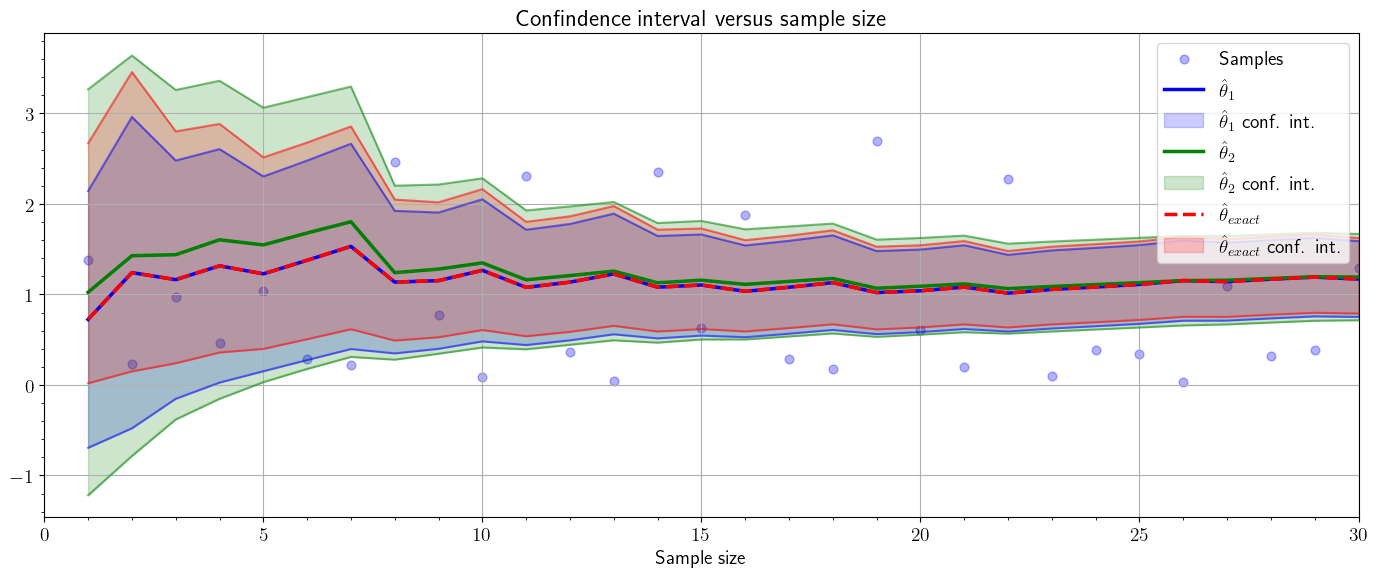

In [28]:
plt.figure(figsize=(14, 6))

draw_confidence_interval(
    left_1,
    right_1,
    theta_1,
    samples,
    ylim=(None, None),
    color_estimation='blue',
    color_interval='blue',
    label_estimation=r'$\hat{\theta}_1$',
    label_interval=r'$\hat{\theta}_1$ conf. int.',
)

draw_confidence_interval(
    left_2,
    right_2,
    theta_2,
    sample=None,
    ylim=(None, None),
    color_estimation='green',
    color_interval='green',
    label_estimation=r'$\hat{\theta}_2$',
    label_interval=r'$\hat{\theta}_2$ conf. int.',
)

draw_confidence_interval(
    left_exact,
    right_exact,
    theta_exact,
    sample=None,
    ylim=(None, None),
    color_estimation='red',
    ls_estimation='--',
    color_interval='red',
    label_estimation=r'$\hat{\theta}_{{exact}}$',
    label_interval=r'$\hat{\theta}_{exact}$ conf. int.',
)

plt.xlim((0, N))
plt.legend(loc='best')
plt.xlabel('Sample size')
plt.minorticks_on()
plt.grid()
plt.title('Confindence interval versus sample size')
plt.tight_layout()

Что можно теперь сказать про эти доверительные интервалы?

Можно видеть, что с ростом размера выборки асимптотические доверительные интервалы стремятся к точному, как и оценка параметра распределение $\theta$

**3.** Для всех исследуемых критериев оцените вероятность ошибки 1 рода и постройте для них доверительный интервал. Пример оценки стоит посмотреть в семинарском ноутбуке, но в данном задании требуется построить такую оценку в засимимости от размера выборки.

In [29]:
def get_coverage_rate(
    left: np.ndarray, 
    right: np.ndarray, 
    theta: float
    ) -> np.ndarray:
    
    return np.mean(
        (left <= theta) & (theta <= right),
        axis=-1,
    )
    
# for error 1/2 probability conf. intervals
def conf_int_binomial(sample_len, sample_sum, alpha=0.95):
    
    p_hat = sample_sum / sample_len
    sigma = np.sqrt((p_hat * (1 - p_hat)) / sample_len)
    q = sp.stats.norm.ppf((1 + alpha) / 2)
    C = (p_hat - q * sigma, p_hat + q * sigma)
    return C

In [30]:
num_experiments = 100_000  # Количество выборок
N = 30
theta_true = 1.  # Истинное значение параметра

# Генерируем все выборки
samples = np.random.exponential(scale=1/theta_true, size=(num_experiments, N))

In [31]:
# Считаем интервал Вальда и долю покрытия
_, left_1, right_1 = conf_int_cumulative(samples, conf_int_1, alpha=alpha)
coverage_rate_asymptotic_1 = get_coverage_rate(left_1, right_1, theta_true)

_, left_2, right_2 = conf_int_cumulative(samples, conf_int_2, alpha=alpha)
coverage_rate_asymptotic_2 = get_coverage_rate(left_2, right_2, theta_true)

# Считаем интервал на основе максимума и долю покрытия
_, left_exact, right_exact = conf_int_cumulative(samples, conf_int_exact, alpha=alpha)
coverage_rate_exact = get_coverage_rate(left_exact, right_exact, theta_true)

sample_size_grid = np.arange(N) + 1

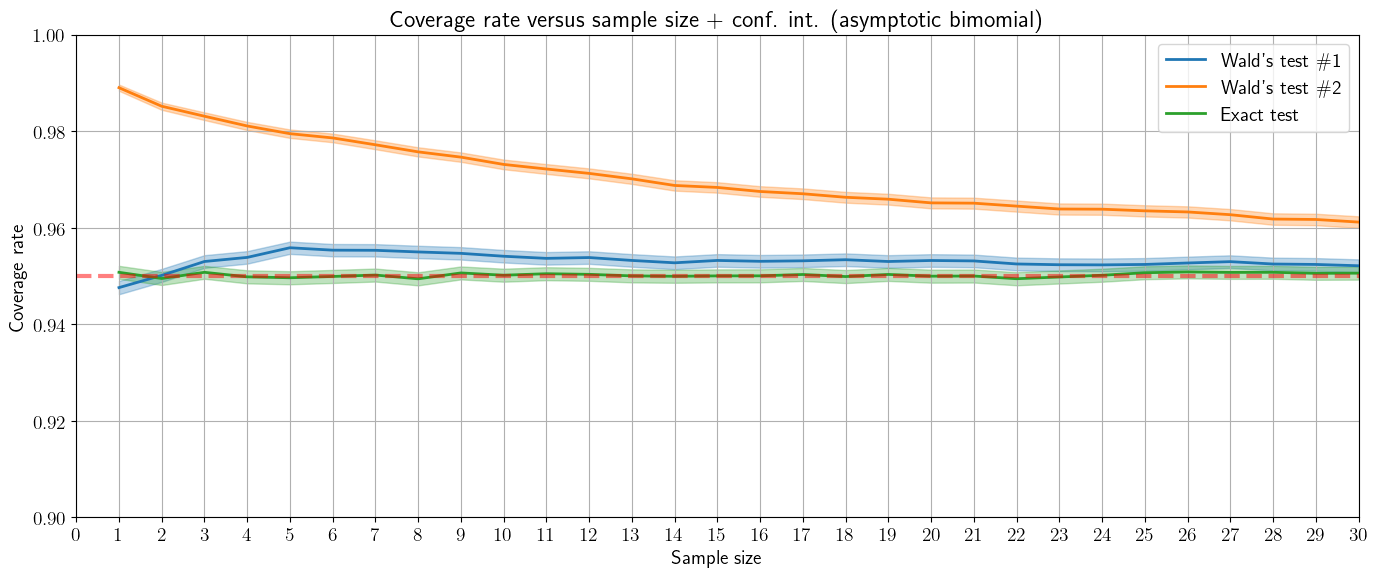

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(sample_size_grid, coverage_rate_asymptotic_1, lw=2, label=r"Wald's test \#1")
plt.fill_between(sample_size_grid, *conf_int_binomial(num_experiments, np.sum((left_1 <= theta_true) & (theta_true <= right_1), axis=1)), alpha=0.3, color='C0')

plt.plot(sample_size_grid, coverage_rate_asymptotic_2, lw=2, label=r"Wald's test \#2")
plt.fill_between(sample_size_grid, *conf_int_binomial(num_experiments, np.sum((left_2 <= theta_true) & (theta_true <= right_2), axis=1)), alpha=0.3, color='C1')

plt.plot(sample_size_grid, coverage_rate_exact, lw=2, label=r'Exact test')
plt.fill_between(sample_size_grid, *conf_int_binomial(num_experiments, np.sum((left_exact <= theta_true) & (theta_true <= right_exact), axis=1)), alpha=0.3, color='C2')

plt.hlines(alpha, 0, N, lw=3, color='red', linestyles='--', alpha=0.5)
plt.ylim((0.9, 1.0))
plt.xlim((0, N))
plt.xticks(np.arange(N+1))
plt.legend()
plt.grid()
plt.xlabel('Sample size')
plt.ylabel('Coverage rate')
plt.title('Coverage rate versus sample size + conf. int. (asymptotic bimomial)')
plt.tight_layout();

Какие критерии не контролируют вероятность ошибки 1 рода на уровне 5\%?

Из графика можно видеть, что точный критерий обеспечивает вероятность ошибки 1 рода 5% для всех размеров выборок, в то время как асимптотические стремятся к этому уровню при росте $n$. Асимптотический критерий 2 для малых $n$ значительно занижает вероятность ошибки 1 рода (то может давать избыточно широкий доверительный интервал).

Оцените мощность критериев в зависимости от значения $\theta$ и размера выборки. Пример такой оценки есть в семинарском ноутбуке.

In [33]:
def calculate_power(
    theta: float, 
    theta_0: float,
    conf_int: tp.Callable, 
    n: int,
    alpha: float = 0.95,
    n_iter: int = 10_000
    ) -> float:
    
    rej_cnt = 0 
    for _ in range(n_iter):
        X = np.random.exponential(scale=1/theta, size=(n, ))
        rej_cnt += criterion(X, theta_0, conf_int, 1 - alpha)
    return rej_cnt / n_iter

def calculate_power_seq(
        sample_size_seq: np.ndarray,
        theta_seq: np.ndarray,
        theta_0: float,
        conf_int: tp.Callable,
        alpha:float = 0.95,
        n_iter: int = 10_000
    ) -> np.ndarray:
    
    powers = np.zeros((len(sample_size_seq), len(theta_seq)))
    for i, n in enumerate(tqdm.tqdm(sample_size_seq, leave=False)):
        for j, t in enumerate(theta_seq):
            powers[i, j] = calculate_power(
                theta=t, 
                theta_0=theta_0, 
                conf_int=conf_int, 
                n=n, 
                alpha=alpha,
                n_iter=n_iter
            )
            
    return powers

def plot_power(
        theta_seq: np.ndarray,
        sample_size_seq: np.ndarray,
        powers: np.ndarray, 
        title: str = ""
    ) -> None:
    plt.figure(figsize=(8, 4))
    for i, n in enumerate(sample_size_seq):
        plt.plot(theta_seq, powers[i], label=f"n = {n}", lw=3)
    plt.xlabel(r"$\theta$")
    plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3, alpha=0.5); 
    plt.minorticks_on()
    plt.ylabel("Power")
    plt.title(title)
    plt.legend()
    plt.show()

In [34]:
theta_0 = 1.
alpha = 0.95

num_exp = 10_000

theta_seq = np.linspace(0.1, 3, 30)
sample_size_seq = np.array([10, 50, 100, 250, 500])

In [35]:
powers_1 = calculate_power_seq(
    sample_size_seq,
    theta_seq,
    theta_0,
    conf_int=conf_int_1,
    alpha=alpha,
    n_iter=num_exp
)

powers_2 = calculate_power_seq(
    sample_size_seq,
    theta_seq,
    theta_0,
    conf_int=conf_int_2,
    alpha=alpha,
    n_iter=num_exp
)

powers_exact = calculate_power_seq(
    sample_size_seq,
    theta_seq,
    theta_0,
    conf_int=conf_int_exact,
    alpha=alpha,
    n_iter=num_exp
)

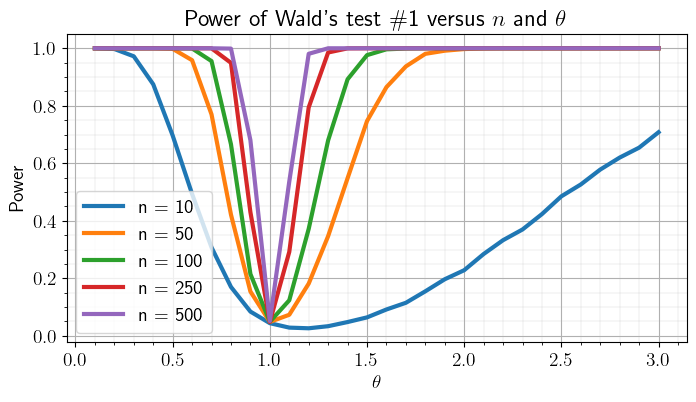

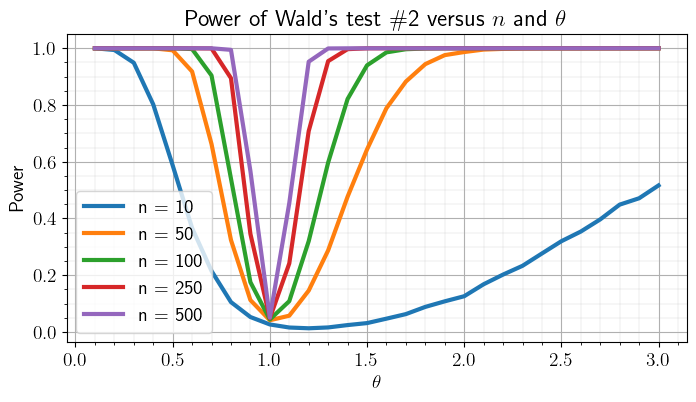

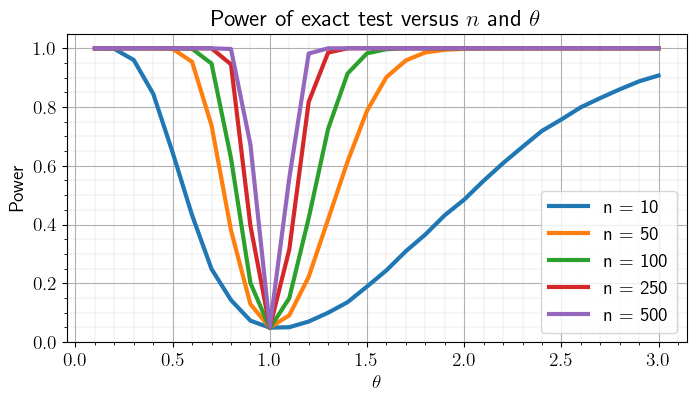

In [36]:
plot_power(
    theta_seq, 
    sample_size_seq, 
    powers_1, 
    r"Power of Wald's test \#1 versus $n$ and $\theta$"
)

plot_power(
    theta_seq, 
    sample_size_seq, 
    powers_2, 
    r"Power of Wald's test \#2 versus $n$ and $\theta$"
)

plot_power(
    theta_seq, 
    sample_size_seq, 
    powers_exact, 
    r"Power of exact test versus $n$ and $\theta$"
)

Что можно теперь сказать про эти критерии?

Из графиков доли покрытия можно видеть, что точный критерий обеспечивает вероятность ошибки 1 рода 5% для всех размеров выборок, в то время как асимптотические стремятся к этому уровню при росте $n$. Асимптотический критерий 2 для малых $n$ значительно занижает вероятность ошибки 1 рода (то может давать избыточно широкий доверительный интервал).

Из графиков мощностей критериев можно видеть, что точный критерий заметно превосходит асимптотические, особенно для малых размеров выборки и вдали от реального значение параметра $\theta=1$, иными словами имеет более низкую вероятность ошибки 2 рода. При этом первый асимптотический критерий имеет мощность несколько выше, чем первый, опять же, особенно для малых $n$ и больших отклонений параметра $\theta$.

Для больших $n$ разница между критериями незначительная, что естественно, так как асимптотические критерии становятся точнее при росте $n$ и приближаются к точному критерию.

---
### Задача 3.

В этой задаче мы продолжим исследовать <a href="https://raw.githubusercontent.com/bdemeshev/em301/master/datasets/flats_moscow.txt">данные</a> о стоимости квартир в Москве.	Описание данных доступно по <a href="https://github.com/bdemeshev/em301/blob/master/datasets/flats_moscow_description.txt">ccылке</a>. Перед выполнением задачи рекомендуется ознакомиться с семинарским ноутбуком.
	
Обучите линейную регрессионную модель для предсказания цены квартиры от всех других параметров.

n – номер квартиры по порядку

price – цена квартиры в $1000

totsp – общая площадь квартиры, кв.м.

livesp жилая площадь квартиры, кв.м.

kitsp – площадь кухни, кв.м.

dist – расстояние от центра в км.

metrdist – расстояние до метро в минутах

walk – пешком от метро, 0 – на транспорте

brick – кирпичный, монолит ж/б, 0 – другой

floor – этаж кроме первого и последнего, 0 – иначе.

code – число от 1 до 8, при помощи которого мы группируем наблюдения по подвыборкам:

1. Наблюдения сгруппированы на севере, вокруг Калужско-Рижской линии
метрополитена
2. Север, вокруг Серпуховско-Тимирязевской линии метрополитена
3. Северо-запад, вокруг Замоскворецкой линии метрополитена
4. Северо-запад, вокруг Таганско-Краснопресненской линии метрополитена
5. Юго-восток, вокруг Люблинской линии метрополитена
6. Юго-восток, вокруг Таганско-Краснопресненской линии метрополитена
7. Восток, вокруг Калиниской линии метрополитена
8. Восток, вокруг Арбатско-Покровской линии метрополитена


In [37]:
flats = pd.read_csv("data/flats_moscow.txt", sep='\t')
del flats['n']
flats.head()

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,81,58,40,6.0,12.5,7,1,1,1,3
1,75,44,28,6.0,13.5,7,1,0,1,6
2,128,70,42,6.0,14.5,3,1,1,1,3
3,95,61,37,6.0,13.5,7,1,0,1,1
4,330,104,60,11.0,10.5,7,0,1,1,3


Обработаем категориальные признаки при помощи one-hot encoding'а. Если признак имеет $k$ категорий, то опишем его $k-1$ бинарным признаком. 

In [38]:
categorical_cols = ['walk', 'brick', 'floor', 'code'] 
continuous_cols = ['totsp', 'livesp', 'kitsp', 'dist', 'metrdist']

In [39]:
flats[continuous_cols].describe()

,totsp,livesp,kitsp,dist,metrdist
count,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000
mean,73.084314,46.337255,8.898529,11.015686,8.117157
std,15.123450,7.894348,2.787073,3.375539,3.815574
min,44.000000,28.000000,5.000000,3.000000,1.000000
25%,62.000000,42.000000,7.000000,9.000000,5.000000
50%,73.500000,45.000000,9.000000,12.000000,7.000000
75%,79.000000,50.000000,10.000000,13.500000,10.000000
max,192.000000,102.000000,25.000000,17.000000,20.000000


Среднее для бинарных признаков - относительная частота встречаемости объекта выборки данной категории для данного признака (единица минус сумма других категроий - относительная частота оставшейся категории).

In [40]:
feature_names = flats.columns[1:].to_list()  # w/o price (target)
feature_names_cont_str = ' + '.join(continuous_cols)
feature_names_cat_str = ' + '.join(map(lambda s: f'C({s})', categorical_cols))
feature_names_str = f'{feature_names_cont_str} + {feature_names_cat_str}'
feature_names_str

'totsp + livesp + kitsp + dist + metrdist + C(walk) + C(brick) + C(floor) + C(code)'

In [41]:
ols_model = smf.ols(f'price ~ {feature_names_str}', flats)
ols_result = ols_model.fit()  # use heteroskedasticity-consistent estimator (HC3)

Проверьте гипотезы о незначимости признаков и постройте доверительные интервалы для коэффициентов модели.

Воспользуемся методом `summary`. Для каждого коэффициента построены доверительные интервалы на уровня доверия 0.95.

Можно видеть, что p-value для `C(brick)[T.1]` (то есть информация о материале дома), `C(code)[T.2]`, `C(code)[T.4]` и `C(code)[T.8]` (некоторые районы) превышают 0.05, поэтому 

In [42]:
print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     324.1
Date:                Thu, 31 Oct 2024   Prob (F-statistic):               0.00
Time:                        22:39:00   Log-Likelihood:                -9701.0
No. Observations:                2040   AIC:                         1.943e+04
Df Residuals:                    2024   BIC:                         1.952e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -28.3732      5.496     -5.162

Определите признаки желаемой для себя квартиры в Москве и постройте предсказательный интервал ее цены.

*Для выполнения этого и следующего пунктов обратите внимание на доверительные интервалы в линейной регрессии, рассказанные на лекции. В случае гетероскедастичности нужно использовать специальную оценку матрицы ковариаций, которую можно получить из `statsmodels`, примеры смотрите в семинарском ноутбуке.*

Пусть желаемая квартира будет обладать следующими признаками:

In [43]:
desired_flat_dict = {
    'totsp' : 120,
    'livesp' : 50,
    'kitsp' : 20,
    'dist' : 10,
    'metrdist' : 10,
    'walk' : 1,
    'brick' : 1,
    'floor' : 1,
    'code' : 4
}

desired_flat = pd.DataFrame(desired_flat_dict, index=[0])
desired_flat

,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,120,50,20,10,10,1,1,1,4


Найдем оценку стоимости кваритиры и доверительные интервалы. Используются устойчивая оценка матрицы ковариации HC3, нет предположения о гомоскедастичности. Нас интересует предсказаьельный интервал (`obs_ci_lower`; `obs_ci_upper`), который учитывает ошибки измерений (`mean_ci` не учитывет, принимает во внимание только неопределенность предсказания средней величины стоимости).

In [44]:
desired_flat_pred = ols_result.get_prediction(desired_flat).summary_frame(alpha=0.05)
desired_flat_pred

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,248.911364,4.42238,240.238471,257.584256,192.874242,304.948486


In [45]:
display(Math(rf'\text{{price}} \in ({desired_flat_pred['mean'].item():.3f} \pm'
             rf'{(desired_flat_pred['obs_ci_upper'] - desired_flat_pred['obs_ci_lower']).item()/2:.3f})'
             rf'\; \text{{at confidence level }} 0.95'))  # ci is symmetric

<IPython.core.display.Math object>

Зафиксируйте все параметры, кроме площади квартиры и постройте доверительную ленту для цены квартиры. Иначе говоря, для каждого значения площади квартиры необходимо построить доверительный интервал для среднего значения цены квартиры. Аналогичным образом постройте предсказательную ленту.

In [46]:
# choose totsp series in the range from sum of living area and kitched area to the max observed area in training set
totsp_series = np.linspace(start=(desired_flat['livesp'] + desired_flat['kitsp']).item(), stop=flats['totsp'].max(), num=100)

desired_flat_series_dict = desired_flat_dict
desired_flat_series_dict['totsp'] = totsp_series
for k in desired_flat_series_dict.keys():
    if k != 'totsp':
        desired_flat_series_dict[k] = np.array([desired_flat_series_dict[k]] * len(totsp_series))
        
desired_flat_series = pd.DataFrame(desired_flat_series_dict)
desired_flat_series.head()

,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,70.000000,50,20,10,10,1,1,1,4
1,71.232323,50,20,10,10,1,1,1,4
2,72.464646,50,20,10,10,1,1,1,4
3,73.696970,50,20,10,10,1,1,1,4
4,74.929293,50,20,10,10,1,1,1,4


In [47]:
desired_flat_series_pred = ols_result.get_prediction(desired_flat_series).summary_frame(alpha=0.05)

In [48]:
desired_flat_0_totsp = desired_flat.copy()
desired_flat_0_totsp['totsp'] = 0
desired_flat_0_totsp

,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,0,50,20,10,10,1,1,1,4


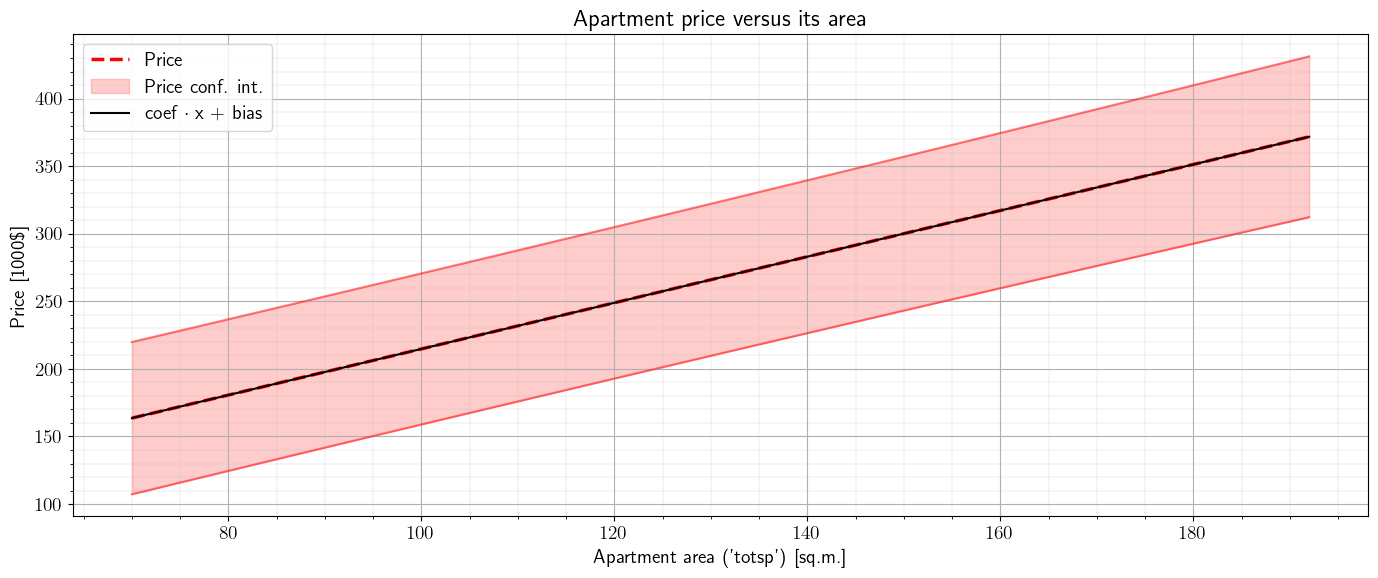

In [49]:
plt.figure(figsize=(14, 6))

draw_confidence_interval(
    desired_flat_series_pred['obs_ci_lower'],
    desired_flat_series_pred['obs_ci_upper'],
    desired_flat_series_pred['mean'],
    x=totsp_series,
    sample=None,
    ylim=(None, None),
    color_estimation='red',
    ls_estimation='--',
    color_interval='red',
    label_estimation=r'Price',
    label_interval=r'Price conf. int.',
)

bias = ols_result.predict(desired_flat_0_totsp).item()
coef = ols_result.params['totsp'].item()

plt.plot(totsp_series, coef * totsp_series + bias, ls='-', color='black', label=r'coef $\cdot$ x + bias')

plt.legend(loc='best')
plt.xlabel("Apartment area ('totsp') [sq.m.]")
plt.ylabel("Price [1000\\$]")
plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3, alpha=0.5); 
plt.minorticks_on()
plt.title('Apartment price versus its area')
plt.tight_layout()

**Вывод:**

Для предсказания стоимости квартиры была использована линейная регрессионая модель МНК. Поэтому изменяя один параметр модели (площадь квартиры), стоимость квариты изменяется линейно с коэффициентом наклона в точности равным коэффициенту при признаке `totsp` и совободному коэффициценту, равному сумме остальных признаков, умноженных на соответсвтующие признаки. Доверительный интервал приблизительно постоянной ширины, немонотонно увеличивается при росте площади кваритры (пересчитвается оценка дисперсии на каждом новом векторе признаков)

---
### Задача 4.

Кардиотокография (КТГ) — непрерывная одновременная регистрация частоты сердечных сокращений плода и
тонуса матки с графическим изображением физиологических сигналов на калибровочной ленте. В настоящее
время КТГ является ведущим методом наблюдения за характером сердечной деятельности, который из-за
своей простоты в проведении, информативности и стабильности получаемой информации практически
полностью вытеснил из клинической практики фоно- и электрокардиографию плода.

Для облегчения задачи диагностики, результаты кардиотокографии некоторых эмбрионов были
классифицированы специалистами на нормальные и патологические. По показаниям приборов было
сгенерировано некоторое количество признаков.

**1.** Скачайте данные по ссылке: https://archive.ics.uci.edu/ml/datasets/cardiotocography. 
Данные расположены в листе `Data`. Рассматриваемые нами признаки указаны в листе Description в колонке Features. Целевой меткой является столбец `NSP`. Для анализа мы не будем рассматривать данные, целевой меткой которой является `Suspect`.

Описание признаков и метки класса:

* LB - FHR baseline (beats per minute)
* AC - # of accelerations per second
* FM - # of fetal movements per second
* UC - # of uterine contractions per second
* DL - # of light decelerations per second
* DS - # of severe decelerations per second
* DP - # of prolongued decelerations per second
* ASTV - percentage of time with abnormal short term variability
* MSTV - mean value of short term variability
* ALTV - percentage of time with abnormal long term variability
* MLTV - mean value of long term variability
* Width - width of FHR histogram
* Min - minimum of FHR histogram
* Max - Maximum of FHR histogram
* Nmax - # of histogram peaks
* Nzeros - # of histogram zeros
* Mode - histogram mode
* Mean - histogram mean
* Median - histogram median
* Variance - histogram variance
* Tendency - histogram tendency
* CLASS - FHR pattern class code (1 to 10) 
* NSP - fetal state class code (N=normal (1); S=suspect (2); P=pathologic(3))

**Изменим целевую метку в соответствии с условием: NSP = 1 - Suspect, NSP = 0 - Normal или Pathologic**. То есть классификаци OvR для Suspect

In [50]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
pd.options.mode.copy_on_write = True

# fetch dataset 
cardiotocography = fetch_ucirepo(id=193) 

ctg_dataset = cardiotocography.data.features.join(cardiotocography.data.targets)
del ctg_dataset['CLASS']

In [51]:
ctg_dataset.loc[ctg_dataset['NSP'] == 1, 'NSP'] = 0
ctg_dataset.loc[ctg_dataset['NSP'] == 3, 'NSP'] = 0
ctg_dataset.loc[ctg_dataset['NSP'] == 2, 'NSP'] = 1

Разделим данные на тренировочную и тестовую выборки (с одинаковой долей каждого класса)

In [52]:
ctg_dataset_train, ctg_dataset_test = train_test_split(
    ctg_dataset, 
    test_size=0.2, 
    shuffle=True, 
    #stratify=ctg_dataset['NSP'], 
    random_state=0
)

X_train = ctg_dataset_train.copy()
y_train = ctg_dataset_train['NSP']
del X_train['NSP']

X_test = ctg_dataset_test.copy()
y_test = ctg_dataset_test['NSP']
del X_test['NSP']

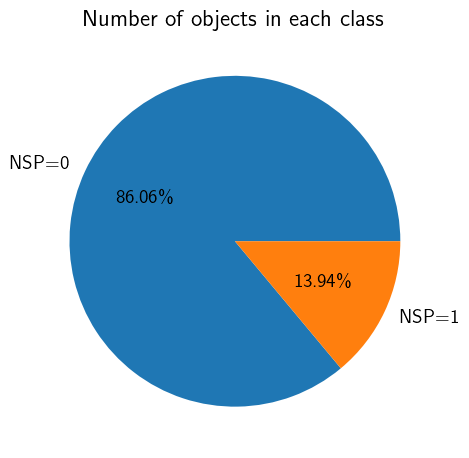

In [53]:
y_cnt = y_train.value_counts()

plt.figure()
plt.title('Number of objects in each class')
plt.pie(
    x=y_cnt, 
    labels=[f'NSP={i}' for i in y_cnt.index],
    autopct=lambda p:f'{p:.2f}%',
)
plt.tight_layout()

In [54]:
pd.set_option('display.max_columns', None)
feature_names = X_train.columns.to_list()
print('Features:', *feature_names)
display(X_train.head())
display(y_train.head())

Features: LB AC FM UC DL DS DP ASTV MSTV ALTV MLTV Width Min Max Nmax Nzeros Mode Mean Median Variance Tendency


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
1719,131,0.009,0.0,0.004,0.001,0.0,0.0,54,1.5,0,4.0,85,84,169,6,0,151,141,144,22,1
1376,121,0.006,0.0,0.008,0.004,0.0,0.0,24,1.7,0,4.1,72,74,146,4,0,129,121,126,25,1
1454,148,0.004,0.0,0.005,0.000,0.0,0.0,40,0.9,8,11.8,47,126,173,5,0,157,156,158,3,0
1805,143,0.000,0.0,0.001,0.000,0.0,0.0,68,0.3,5,9.4,26,133,159,1,0,144,144,145,1,0
1969,138,0.007,0.0,0.004,0.000,0.0,0.0,59,0.7,0,8.5,43,125,168,1,0,148,145,147,6,0


1719    0
1376    0
1454    0
1805    0
1969    0
Name: NSP, dtype: int64

* Нет признаков, которые уверенно в отдельности разделяют классы. Однако некоторые из них хорошо отделяют один класс от двух других: LB для 2, ASTV для 1, MSTV для 2, ALTV для 1, NSP для 2, Mode для 3, Mean для 3, Median для 3, особенн Tendence для 3 (-1)
* Некоторые признаки обладают заметной дискретной структурой (связанно с подсчетом числа событий или с округлением значений)
* Некоторые признаки имееют значительные выбросы, однако не имея знаний в прикладной области нельзя сразу сделать вывод об ошибочности измерений. 
* Класс Tendency, очевидно, явялется категориальным
* Пожалуй, Variance стоит привести в логарифмическом масштабе - в нем хорошо отделяются 1 и 3 классы

In [55]:
display(X_train.info())
display(X_train.describe())
for fm in feature_names:
    cnt = X_train[fm].value_counts()
    values_str = ', '.join(map(str, cnt.index))
    print(f'Feature {fm:8} has {len(cnt):3} different values{': ' + values_str if len(cnt) < 10 else '' }')

<class 'pandas.core.frame.DataFrame'>
Index: 1700 entries, 1719 to 1653
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        1700 non-null   int64  
 1   AC        1700 non-null   float64
 2   FM        1700 non-null   float64
 3   UC        1700 non-null   float64
 4   DL        1700 non-null   float64
 5   DS        1700 non-null   float64
 6   DP        1700 non-null   float64
 7   ASTV      1700 non-null   int64  
 8   MSTV      1700 non-null   float64
 9   ALTV      1700 non-null   int64  
 10  MLTV      1700 non-null   float64
 11  Width     1700 non-null   int64  
 12  Min       1700 non-null   int64  
 13  Max       1700 non-null   int64  
 14  Nmax      1700 non-null   int64  
 15  Nzeros    1700 non-null   int64  
 16  Mode      1700 non-null   int64  
 17  Mean      1700 non-null   int64  
 18  Median    1700 non-null   int64  
 19  Variance  1700 non-null   int64  
 20  Tendency  1700 non-null   int64 

None

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
count,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000
mean,133.318235,0.003173,0.008804,0.004347,0.001871,0.000003,0.000148,47.045294,1.322000,9.802941,8.246706,70.478235,93.648824,164.127059,4.064118,0.321176,137.651176,134.744706,138.281765,18.585882,0.329412
std,9.738271,0.003850,0.044304,0.002941,0.002945,0.000054,0.000569,17.138592,0.864586,18.404247,5.702345,38.653242,29.414988,17.819654,2.956225,0.698370,16.009086,15.402376,14.203350,28.720308,0.608711
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,68.000000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.500000,7.000000,0.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,23.000000,1.000000
max,159.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,86.000000,6.300000,91.000000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000


Feature LB       has  47 different values
Feature AC       has  20 different values
Feature FM       has  89 different values
Feature UC       has  15 different values
Feature DL       has  16 different values
Feature DS       has   2 different values: 0.0, 0.001
Feature DP       has   6 different values: 0.0, 0.002, 0.001, 0.003, 0.004, 0.005
Feature ASTV     has  74 different values
Feature MSTV     has  53 different values
Feature ALTV     has  87 different values
Feature MLTV     has 240 different values
Feature Width    has 152 different values
Feature Min      has 109 different values
Feature Max      has  83 different values
Feature Nmax     has  18 different values
Feature Nzeros   has   8 different values: 0, 1, 2, 3, 4, 5, 10, 7
Feature Mode     has  85 different values
Feature Mean     has 100 different values
Feature Median   has  88 different values
Feature Variance has 124 different values
Feature Tendency has   3 different values: 0, 1, -1


In [56]:
feature_names_str = '+'.join(feature_names)
feature_names_str

'LB+AC+FM+UC+DL+DS+DP+ASTV+MSTV+ALTV+MLTV+Width+Min+Max+Nmax+Nzeros+Mode+Mean+Median+Variance+Tendency'

Построим гистрограммы и ядерные оценки плотностей распределений каждого признака для всех целевых меток `NSP` 

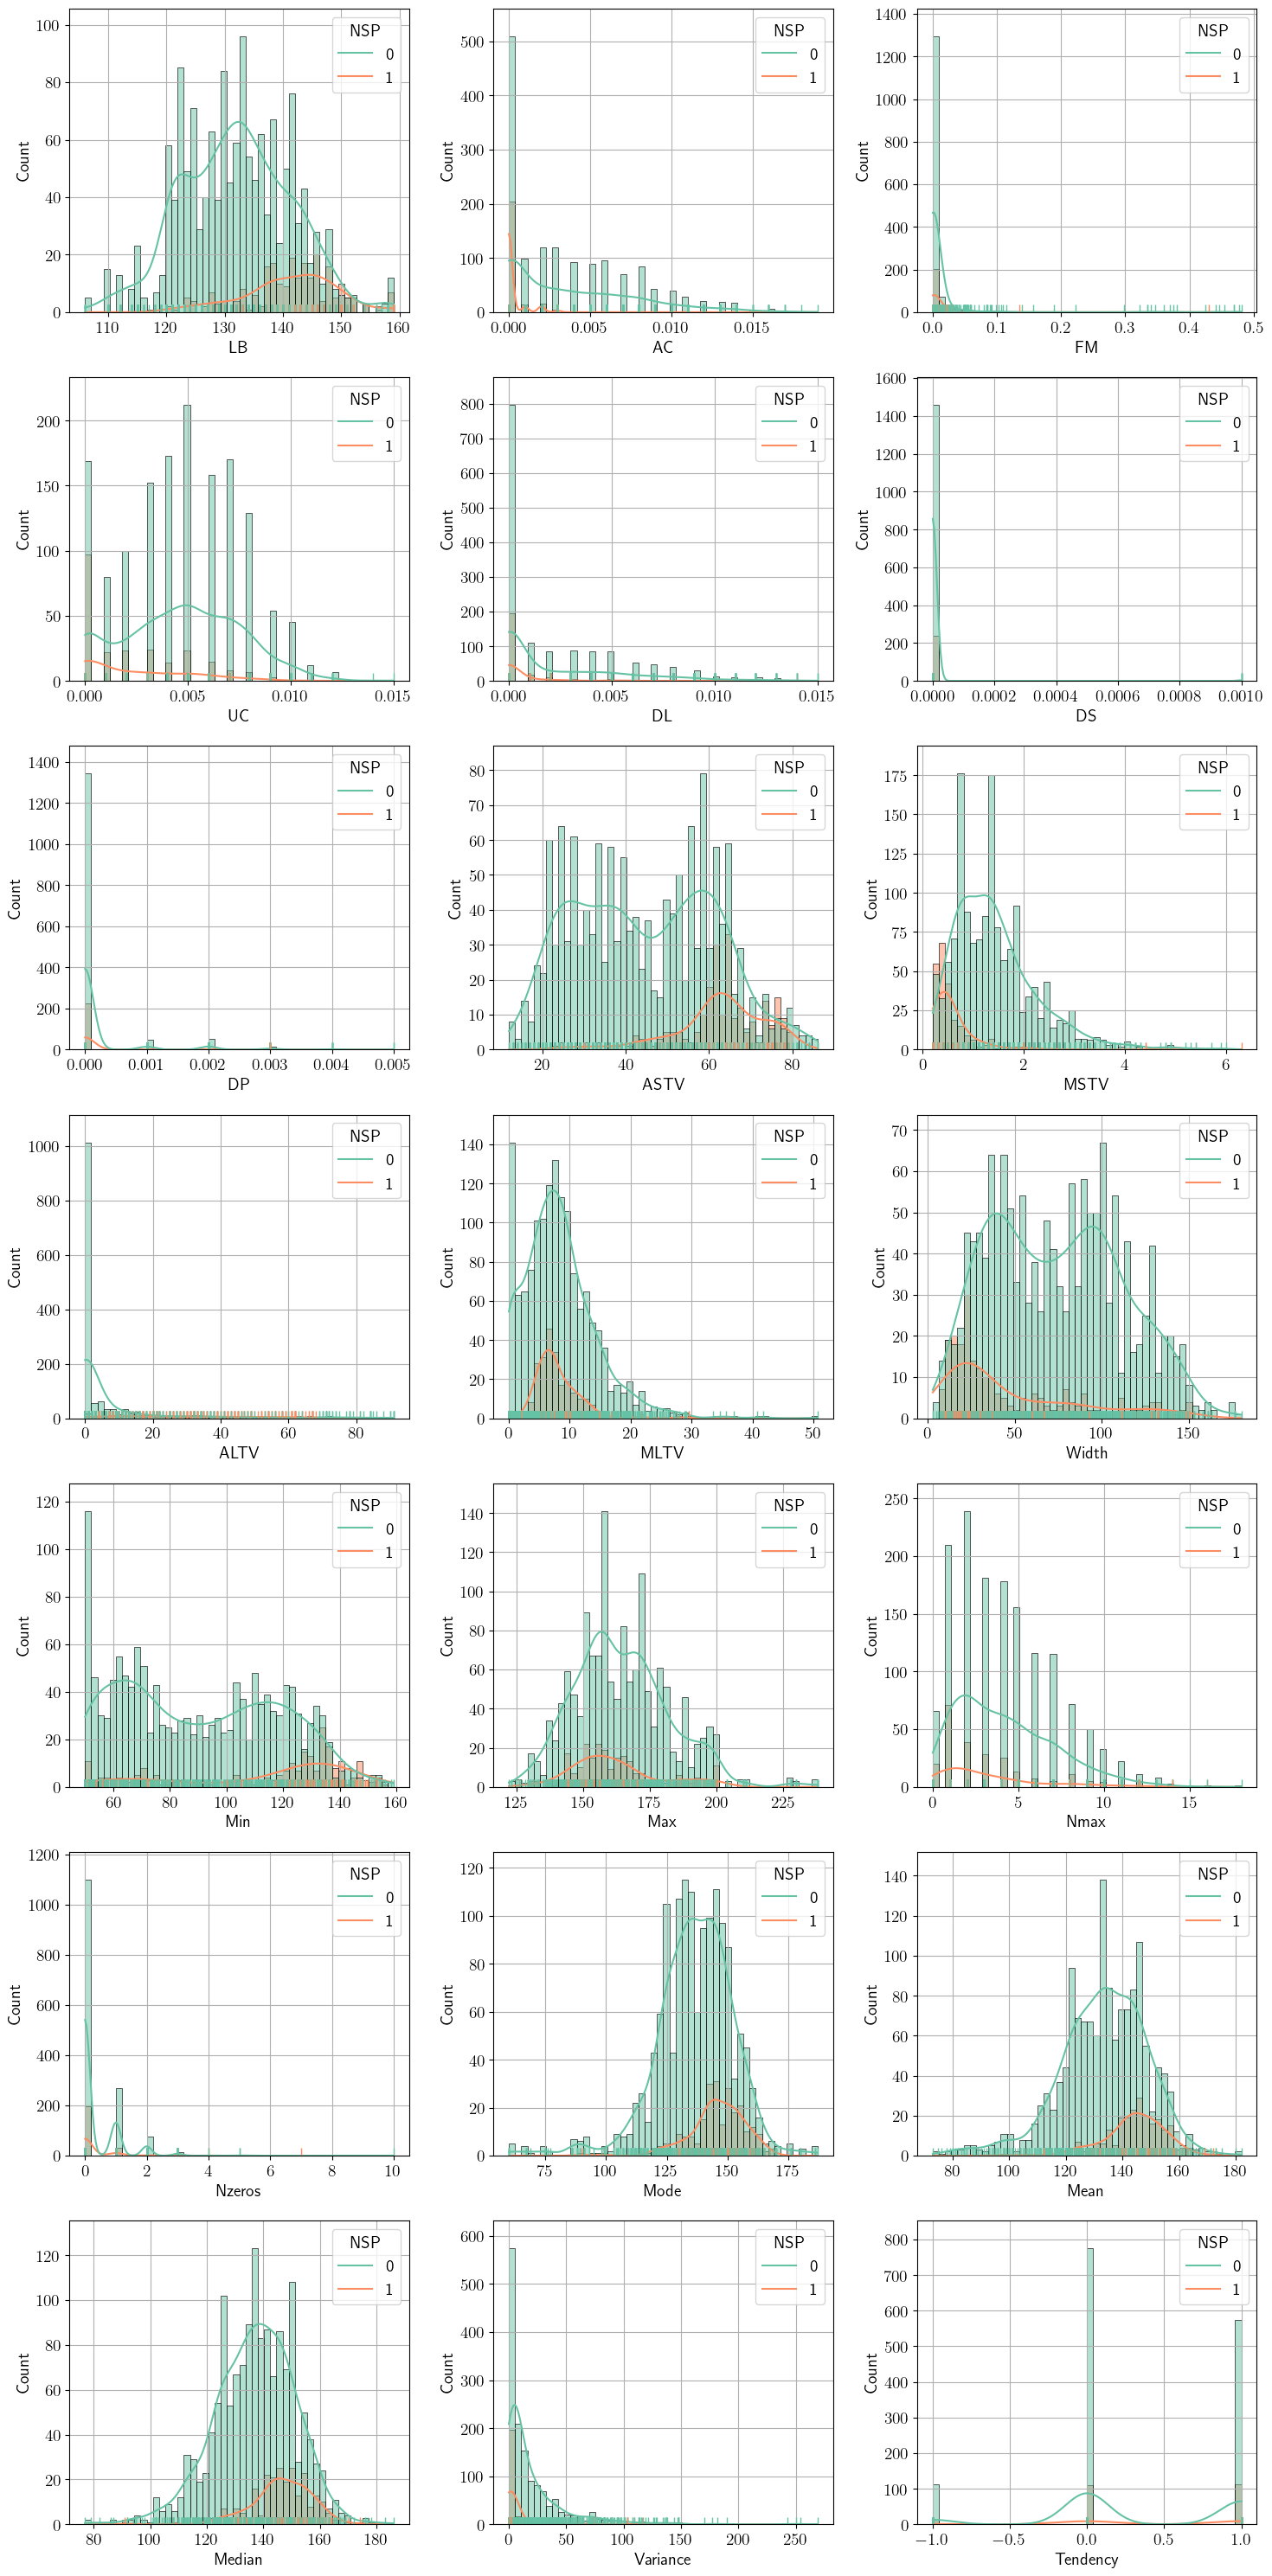

In [57]:
fig, ax = plt.subplots(ncols=3, nrows=7, figsize=(15, 30))
ax = ax.flatten()
for i, col in enumerate(X_train.columns):
    bp = sns.histplot(data=ctg_dataset_train,  x=ctg_dataset_train[col], hue='NSP', ax=ax[i], bins=50, alpha=0.5, kde=True, legend=(i == 0), palette='Set2')
    bp.set(xlabel=None)
    sns.rugplot(data=ctg_dataset_train,  x=ctg_dataset_train[col], hue='NSP', ax=ax[i], palette='Set2')
    ax[i].grid()
    
plt.tight_layout()

Также построим ящики с усами для каждого признака, с разбиением по классам

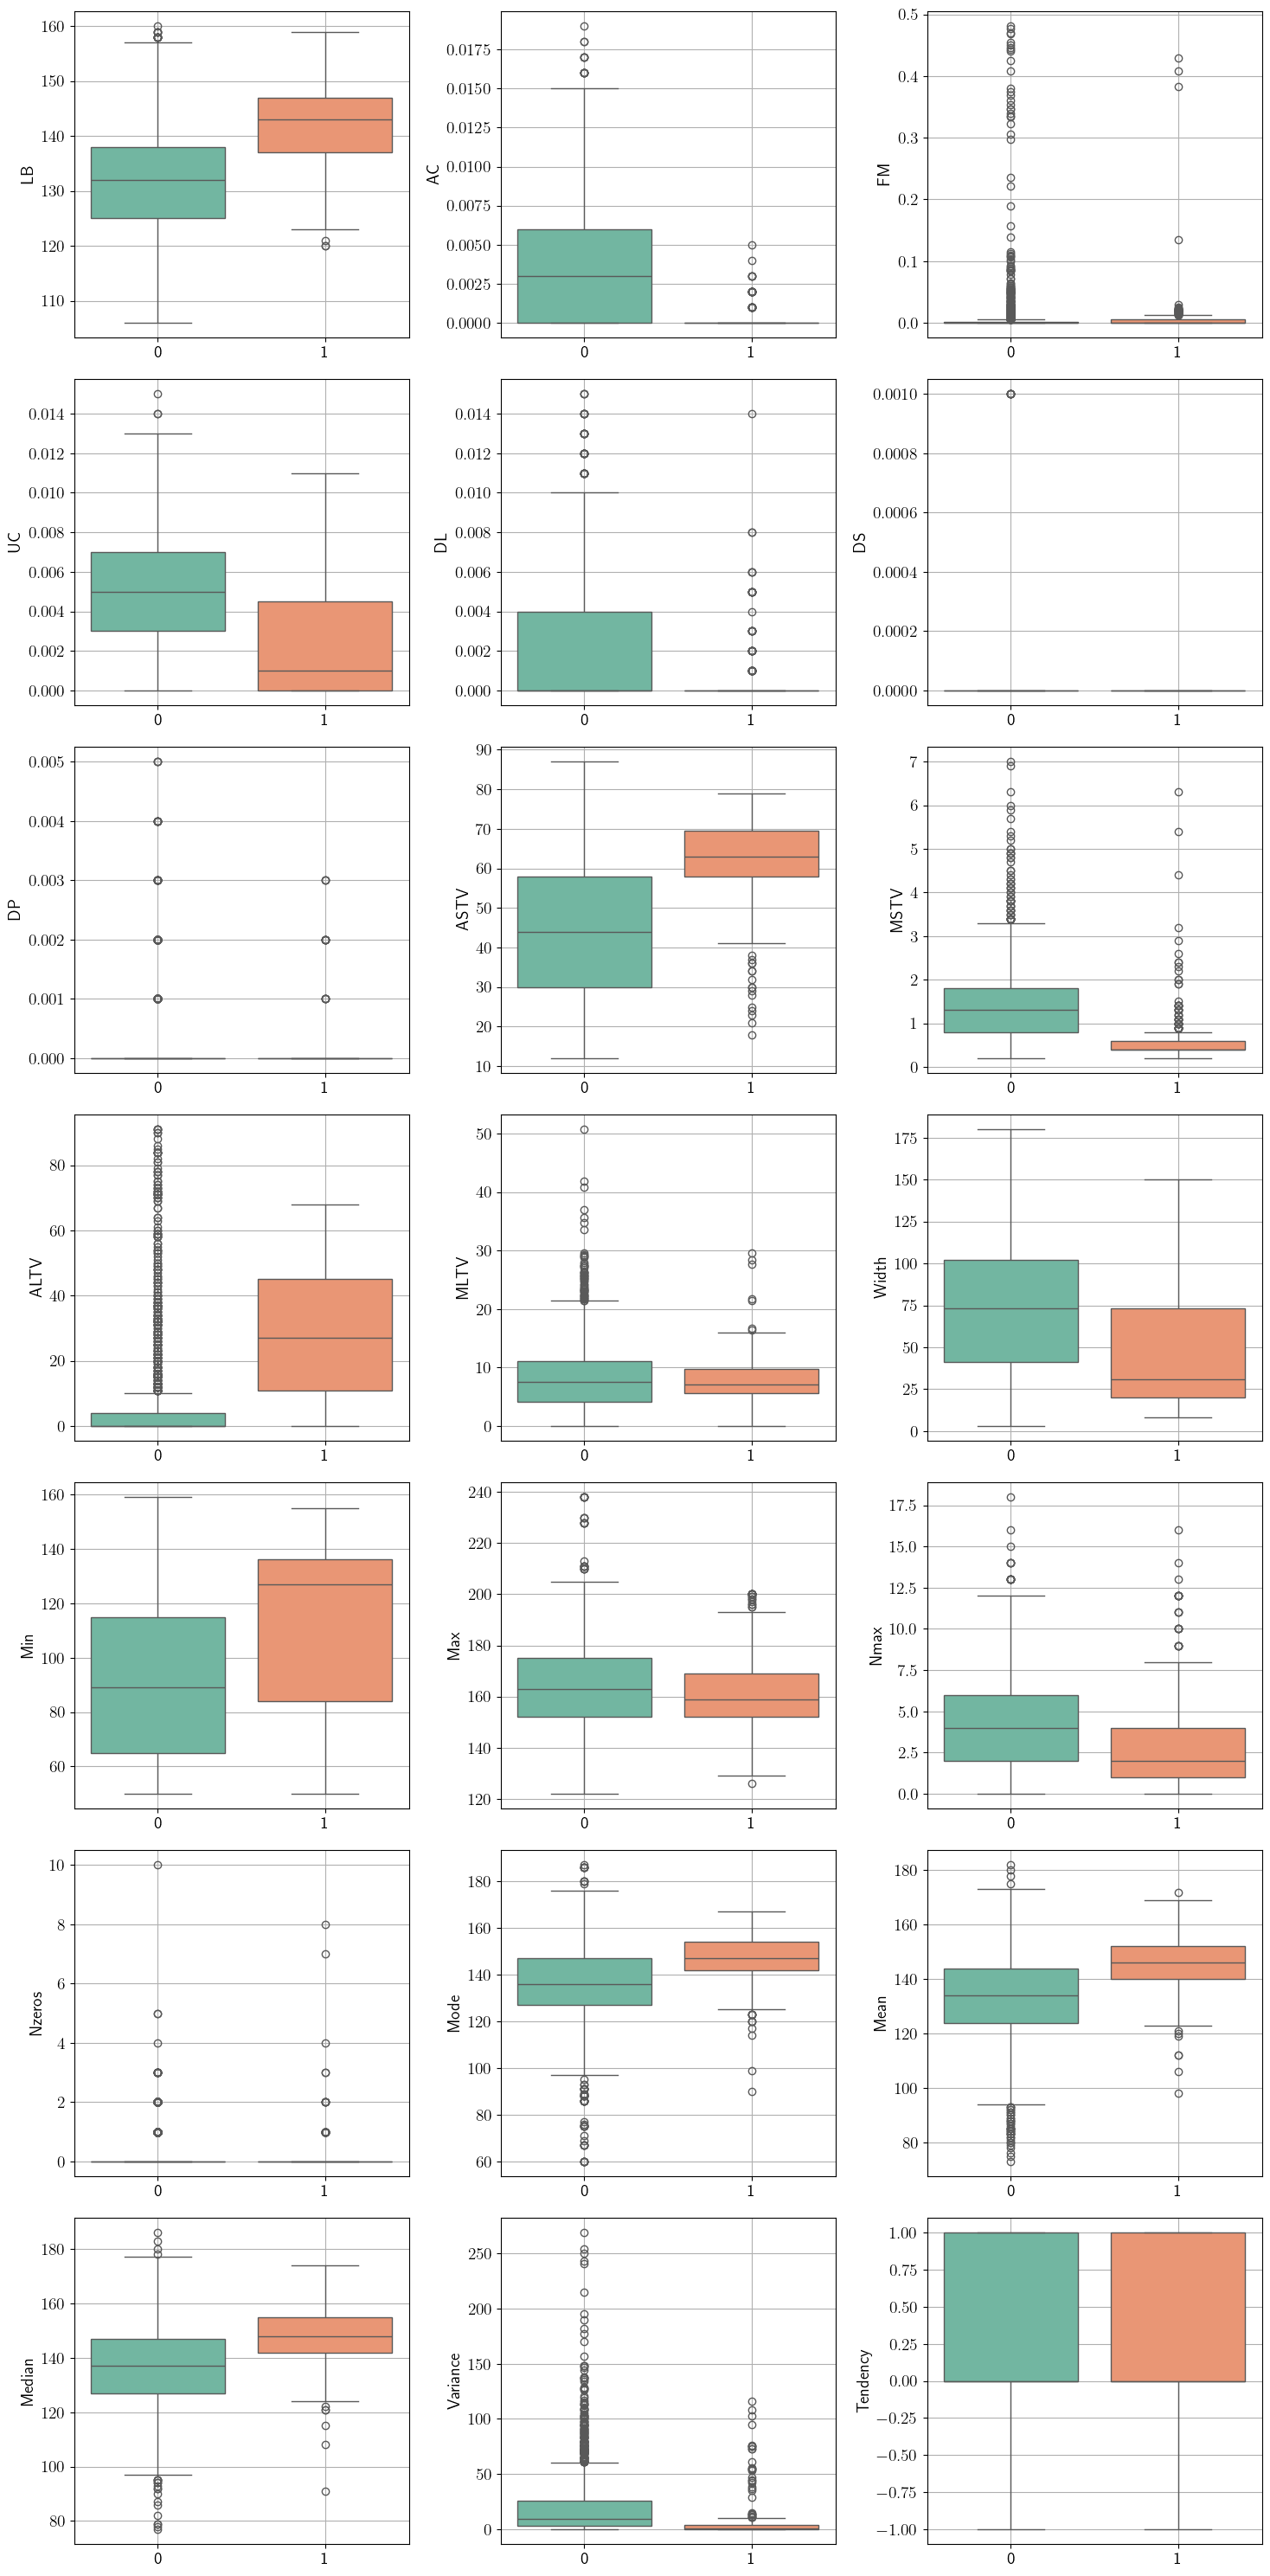

In [58]:
fig, ax = plt.subplots(ncols=3, nrows=7, figsize=(15, 30))
ax = ax.flatten()
for i, col in enumerate(X_train.columns):
    bp = sns.boxplot(data=ctg_dataset, x="NSP", y=ctg_dataset[col], hue="NSP", ax=ax[i], palette='Set2', legend=False)
    bp.set(xlabel=None)
    ax[i].grid()

plt.tight_layout()

**2.** Проведите визуальный анализ данных. Какие признаки лучше всего разделяют классы? Какие преобразования признаков стоит выполнить?

* Некоторые признаки в отдельности позволяют неплохо отделить два класса: LB, ASTV, MSTV, ALTV
* Некоторые признаки обладают заметной дискретной структурой (связанно с подсчетом числа событий или с округлением значений)
* Некоторые признаки имееют значительные выбросы, однако не имея знаний в прикладной области нельзя сразу сделать вывод об ошибочности измерений. 
* Класс Tendency, очевидно, явялется категориальным
* Пожалуй, Variance стоит привести в логарифмическом масштабе

In [59]:
featues_log = ['Variance']
with warnings.catch_warnings(action="ignore"):
    for f in featues_log:
        X_train.loc[:, f] = np.log(X_train[f]+1)
        ctg_dataset_train.loc[:, f] = np.log(ctg_dataset_train[f]+1)
        
with warnings.catch_warnings(action="ignore"):
    for f in featues_log:
        X_test.loc[:, f] = np.log(X_test[f]+1)
        ctg_dataset_test.loc[:, f] = np.log(ctg_dataset_test[f]+1)

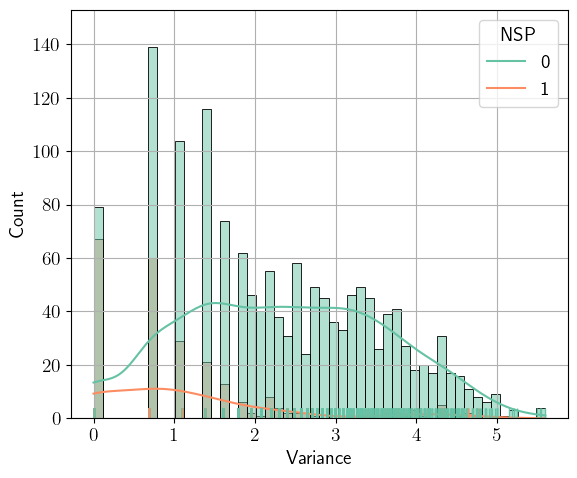

In [60]:
fig, ax = plt.subplots(ncols=1, nrows=1,figsize=(6, 5))
for i, col in enumerate(featues_log):
    bp = sns.histplot(data=ctg_dataset_train,  x=ctg_dataset_train[col], hue='NSP', ax=ax, bins=50, alpha=0.5, kde=True, legend=(i == 0), palette='Set2')
    bp.set(xlabel=None)
    sns.rugplot(data=ctg_dataset_train,  x=ctg_dataset_train[col], hue='NSP', ax=ax, palette='Set2')
    ax.grid()
    
plt.tight_layout()

**3.** Обучите логистическую регрессию по всем признакам. Напечатайте `summary` модели.
В чем причины такого поведения модели? Какие выводы можно сделать? Что нужно сделать, чтобы это исправить?

In [61]:
feature_names_cat = ['Tendency']
feature_names_cont = []
for n in feature_names:
    if n not in feature_names_cat:
        feature_names_cont.append(n);
        
feature_names_cont_str = ' + '.join(feature_names_cont)
feature_names_cat_str = ' + '.join(map(lambda s: f'C({s})', feature_names_cat))
feature_names_str = f'{feature_names_cont_str} + {feature_names_cat_str}'

Standartize non-categorical features

In [62]:
with warnings.catch_warnings(action="ignore"):
    for col in feature_names_cont:
        train_mean = ctg_dataset_train.loc[:, col].mean()
        train_std = ctg_dataset_train.loc[:, col].std(ddof=1)
        ctg_dataset_train.loc[:, col] = (ctg_dataset_train.loc[:, col] - train_mean) / train_std
        
        ctg_dataset_test.loc[:, col] = (ctg_dataset_test.loc[:, col] - train_mean) / train_std

In [ ]:
glm_model = smf.glm(f"NSP ~ {feature_names_str}", ctg_dataset_train, family=sm.families.Binomial())
glm_results = glm_model.fit()

In [ ]:
y_pred_train = (glm_results.predict(ctg_dataset_train) > 0.5).astype(int)
y_pred_test = (glm_results.predict(ctg_dataset_test) > 0.5).astype(int)

In [65]:
print('Report on train:\n'+classification_report(y_true=ctg_dataset_train['NSP'], y_pred=y_pred_train))
print('Report on test:\n'+classification_report(y_true=ctg_dataset_test['NSP'], y_pred=y_pred_test))

Report on train:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1463
           1       0.68      0.65      0.66       237

    accuracy                           0.91      1700
   macro avg       0.81      0.80      0.80      1700
weighted avg       0.91      0.91      0.91      1700

Report on test:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       368
           1       0.67      0.67      0.67        58

    accuracy                           0.91       426
   macro avg       0.81      0.81      0.81       426
weighted avg       0.91      0.91      0.91       426



In [66]:
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    NSP   No. Observations:                 1700
Model:                            GLM   Df Residuals:                     1678
Model Family:                Binomial   Df Model:                           21
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Thu, 31 Oct 2024   Deviance:                       692.40
Time:                        22:39:19   Pearson chi2:                 1.36e+03
No. Iterations:                    50   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -5574.8981   8.83e+04  

c:\Users\nazmievairat\anaconda3\envs\python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\nazmievairat\anaconda3\envs\python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
c:\Users\nazmievairat\anaconda3\envs\python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


Обучим регуляризованную модель:

In [67]:
glm_results_reg = glm_model.fit_regularized(method='elastic_net', alpha=1e-7, maxiter=200, L1_wt=0)
y_pred_reg = (glm_results_reg.predict(ctg_dataset_test) > 0.5).astype(int)
glm_results_reg.params

Intercept          -5.136032
C(Tendency)[T.0]    0.484429
C(Tendency)[T.1]    0.519762
LB                 -1.039197
AC                 -3.898197
FM                 -0.085698
UC                 -0.525640
DL                  0.009673
DS                 -0.130524
DP                  0.538493
ASTV                0.969001
MSTV               -0.170460
ALTV               -0.006153
MLTV               -0.172215
Width               0.024523
Min                 0.344540
Max                 0.621928
Nmax                0.474875
Nzeros             -0.054207
Mode                0.047625
Mean                2.947737
Median             -0.702583
Variance            0.177621
dtype: float64

In [68]:
y_pred_reg_train = (glm_results_reg.predict(ctg_dataset_train) > 0.5).astype(int)
y_pred_reg_test = (glm_results_reg.predict(ctg_dataset_test) > 0.5).astype(int)
print('Report on train:\n'+classification_report(y_true=ctg_dataset_train['NSP'], y_pred=y_pred_reg_train))
print('Report on test:\n'+classification_report(y_true=ctg_dataset_test['NSP'], y_pred=y_pred_reg_test))

Report on train:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1463
           1       0.68      0.65      0.66       237

    accuracy                           0.91      1700
   macro avg       0.81      0.80      0.80      1700
weighted avg       0.91      0.91      0.91      1700

Report on test:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       368
           1       0.67      0.67      0.67        58

    accuracy                           0.91       426
   macro avg       0.81      0.81      0.81       426
weighted avg       0.91      0.91      0.91       426



Можно видеть, что модель без регуляризации имеет проблемы со сходимостью: ее явно есть мультиколлинеарность. Если обратить внимание на признак `DS`, то он почти для всех объектов равен 0, поэтому коэффициент при этом признаке почти не влияет на результат и может принимать произвольные значения. Удалим его.

In [69]:
ctg_dataset['DS'].value_counts()

DS
0.000    2119
0.001       7
Name: count, dtype: int64

In [70]:
ctg_dataset.drop(columns=['DS'], inplace=True)
ctg_dataset_train.drop(columns=['DS'], inplace=True)
ctg_dataset_test.drop(columns=['DS'], inplace=True)

In [71]:
feature_names_cont = []
for n in feature_names:
    if n not in feature_names_cat and n != 'DS':
        feature_names_cont.append(n);
        
feature_names_cont_str = ' + '.join(feature_names_cont)
feature_names_cat_str = ' + '.join(map(lambda s: f'C({s})', feature_names_cat))
feature_names_str = f'{feature_names_cont_str} + {feature_names_cat_str}'

**4.** Оставьте только значимые и преобразованные признаки, обучите модель еще раз и проинтерпретируйте полученные результаты. Какой смысл имеют коэффициенты модели?

Коэффициенты модели - скалярные множители перед соотетсвтующим признаком (и свободный коэффициент), линейная модель после подстановки в обратную функцию линеаризации отклика (link function) дает оценку на вероятность принадлежности данного объекта к одному из двух классов.

Ожидаемый отклик:

$y = \mu_\theta(x),\; g(\mu_\theta(x)) = x^\mathsf{T}\theta$,

где $g$ - функция линеаризации ожидаемого отклика. Для бинарной классификации это $g(x)=\log(\frac{x}{1-x})$

Оценка отклика:

$\hat{y} = g^{-1}(x^\mathsf{T}\hat{\theta})$

In [72]:
glm_model_wo_DS = smf.glm(f"NSP ~ {feature_names_str}", ctg_dataset_train, family=sm.families.Binomial())
glm_results_wo_DS = glm_model_wo_DS.fit()
y_pred_wo_DS_train = (glm_results_wo_DS.predict(ctg_dataset_train) > 0.5).astype(int)
y_pred_wo_DS_test = (glm_results_wo_DS.predict(ctg_dataset_test) > 0.5).astype(int)
print(glm_results_wo_DS.summary())
print('Report on train:\n'+classification_report(y_true=ctg_dataset_train['NSP'], y_pred=y_pred_train))
print('Report on test:\n'+classification_report(y_true=ctg_dataset_test['NSP'], y_pred=y_pred_test))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    NSP   No. Observations:                 1700
Model:                            GLM   Df Residuals:                     1679
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -346.20
Date:                Thu, 31 Oct 2024   Deviance:                       692.40
Time:                        22:39:19   Pearson chi2:                 1.37e+03
No. Iterations:                    23   Pseudo R-squ. (CS):             0.3300
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -5.1301      0.598  

Теперь нет проблем со сходимостью. Но остались незначимые признаки с большим p-value. Проведем тест на одновременное равенство нулю всех этих признаков.

In [73]:
features_to_remove = ['FM', 'DL', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Nzeros', 'Mode', 'Median', 'Variance', 'C(Tendency)[T.0]', 'C(Tendency)[T.1]']
features_to_remove_str = ','.join(map(lambda s: f'({s}=0)',features_to_remove))

print(glm_results_wo_DS.f_test(features_to_remove_str))

<F test: F=0.2869997554564488, p=0.9914389430109075, df_denom=1.68e+03, df_num=12>


Удалим их из признаков.

In [74]:
feature_names_cont = []
for n in feature_names:
    if n not in feature_names_cat and n not in features_to_remove and n != 'DS':
        feature_names_cont.append(n);
        
feature_names_cont_str = ' + '.join(feature_names_cont)
#feature_names_cat_str = ' + '.join(map(lambda s: f'C({s})', feature_names_cat))
feature_names_str = f'{feature_names_cont_str}'


glm_model_final = smf.glm(f"NSP ~ {feature_names_str}", ctg_dataset_train, family=sm.families.Binomial())
glm_results_final = glm_model_final.fit()

y_pred_final_train = (glm_results_final.predict(ctg_dataset_train) > 0.5).astype(int)
y_pred_final_test = (glm_results_final.predict(ctg_dataset_test) > 0.5).astype(int)

print(glm_results_final.summary())
print('Report on train:\n'+classification_report(y_true=ctg_dataset_train['NSP'], y_pred=y_pred_final_train))
print('Report on test:\n'+classification_report(y_true=ctg_dataset_test['NSP'], y_pred=y_pred_final_test))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    NSP   No. Observations:                 1700
Model:                            GLM   Df Residuals:                     1690
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -347.99
Date:                Thu, 31 Oct 2024   Deviance:                       695.98
Time:                        22:39:19   Pearson chi2:                 1.50e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.3286
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.6515      0.343    -13.564      0.0

Можно видеть, что после удаления большого числа незначимых признаков качество модели минимум не упало (а по некоторым метрикам классификации возрасло).

**5.** Для некоторых объектов из тестовой выборки оцените вероятность наличия патологии. Постройте также доверительный интервал уровня доверия 0.95 для этой вероятности.

*Указание.* Воспользуйтесь функцией <a href="https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLMResults.get_prediction.html">get_prediction</a> от `GLMResults`. Данная функция возвращает объект <a href="https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.PredictionResults.html">`PredictionResults`</a>, у которого можно вызвать метод `conf_int`.

Проинтерпретируйте границы полученных доверительных интервалов. Как их можно использовать в медицине?

In [75]:
some_test_samples_0 = ctg_dataset_test.loc[ctg_dataset_test['NSP'] == 0]
some_test_samples_1 = ctg_dataset_test.loc[ctg_dataset_test['NSP'] == 1]
some_test_samples = pd.concat((
    some_test_samples_0.iloc[np.random.randint(low=0, high=len(some_test_samples_0-1), size=3)] , 
    some_test_samples_1.iloc[np.random.randint(low=0, high=len(some_test_samples_1-1), size=3)]
))
some_test_samples

,LB,AC,FM,UC,DL,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
1695,0.378072,2.033013,-0.198709,0.562076,0.723009,-0.260383,0.580836,0.321541,-0.532646,-0.113411,1.695117,-1.415905,1.339697,0.316580,0.972011,0.646434,0.730750,1.388281,1.227124,1,0
1226,-0.854180,-0.564403,-0.198709,-0.118016,-0.635130,-0.260383,-0.236034,-0.719420,1.151748,-0.078337,-1.280054,0.895842,-1.297840,-1.374766,-0.459894,-0.415463,-0.308050,-0.442273,-1.119274,0,0
866,0.891510,-0.824145,-0.198709,-0.118016,-0.635130,-0.260383,0.114053,-0.835082,1.097413,-0.201094,-1.383538,1.575767,-0.399955,-1.036497,-0.459894,0.771363,0.860601,0.825033,-1.649382,0,0
485,0.994197,-0.824145,-0.176138,-1.478201,-0.635130,-0.260383,0.989271,-1.066407,0.499725,-0.306314,-1.383538,1.473778,-0.568308,-0.698228,-0.459894,0.396576,0.600900,0.473004,-1.649382,0,1
333,1.096885,-0.824145,0.230150,-1.478201,-0.635130,-0.260383,1.689445,-1.066407,2.781807,0.412689,0.272209,-0.769976,-0.680544,-0.359958,-0.459894,0.459041,0.600900,0.543409,-0.809181,1,1
379,0.788822,-0.564403,0.252721,-1.138155,-0.295595,-0.260383,0.522488,-0.950744,0.391054,-0.148484,-0.503922,0.929838,0.441812,-0.021689,-0.459894,1.021222,0.860601,0.965845,-0.059058,0,1


In [76]:
some_test_samples_pred = glm_results_final.get_prediction(some_test_samples).summary_frame(alpha=0.05)
some_test_samples_pred

,mean,mean_se,mean_ci_lower,mean_ci_upper
0,0.000029,0.000034,0.000003,0.000294
1,0.025113,0.007040,0.014449,0.043300
2,0.355139,0.041478,0.278582,0.439906
3,0.576880,0.047278,0.482596,0.665879
4,0.588749,0.067229,0.453779,0.711566
5,0.548722,0.044748,0.460416,0.634063


Из значений доверительных интервалов можно сделать выводы о том, насколько можно быть уверенным в полученной оценке вероятности класса, каков диапазон значений, в пределах которого находится истинное значение вероятности. Изменяя доверительные уровни доверия можно регулировать уверенность в правильной классификации объекта, чтобы избежать, например, серъезынх побочных эффектов от неверного принятия решения, появляется возможность отказываться от классификации в пограничных случаях.